In [6]:
# load data
from numpy import genfromtxt
import matplotlib.pyplot as plt
%matplotlib qt

data = genfromtxt('data.csv', delimiter=',')

areas  = list(data[:, 0])
prices = list(data[:, 1])
N = len(areas)

print('areas: ', areas)
print('prices: ', prices)
print('data_size: ', N)

areas:  [6.7, 4.6, 3.5, 5.5]
prices:  [9.1, 5.9, 4.6, 6.7]
data_size:  4


areas:  [6.7, 4.6, 3.5, 5.5]
prices:  [9.1, 5.9, 4.6, 6.7]
data_size:  4


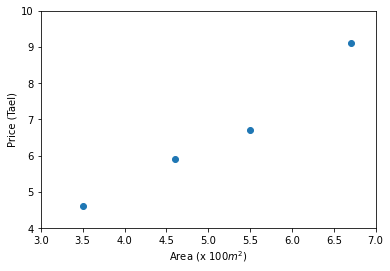

In [1]:
# Naive implementaion

# load data
from numpy import genfromtxt
import matplotlib.pyplot as plt

data = genfromtxt('data.csv', delimiter=',')
areas  = list(data[:,0])
prices = list(data[:,1])
N = len(areas)

print('areas: ', areas)
print('prices: ', prices)
print('data_size: ', N)


# -------------------------------
plt.scatter(areas, prices)
plt.xlabel('Area (x 100$m^2$)')
plt.ylabel('Price (Tael)')
plt.xlim(3,7)
plt.ylim(4,10)
plt.show()

### without average

In [7]:
# forward
def predict(x, w, b):
    return x*w + b

# compute gradient
def gradient(y_hat, y, x):
    dw = 2*x*(y_hat-y)
    db = 2*(y_hat-y)
    
    return (dw, db)

# update weights
def update_weight(w, b, lr, dw, db):
    w_new = w - lr*dw
    b_new = b - lr*db
    
    return (w_new, b_new)

In [8]:
# init weights
b = 0.04
w = -0.34
lr = 0.01

# how long
epoch_max = 10
losses = [] # for debug

for epoch in range(epoch_max):
    
    # for an epoch    
    for i in range(N):
        
        # get a sample
        x = areas[i]
        y = prices[i]       
        
        # predict y_hat
        y_hat = predict(x, w, b)

        # compute loss
        loss = (y_hat-y)*(y_hat-y)
        
        # for debug
        losses.append(loss)

        # compute gradient
        (dw, db) = gradient(y_hat, y, x)

        # update weights
        (w, b) = update_weight(w, b, lr, dw, db)
        
print(w, b)

1.2126016661608625 0.22516769158419553


### With averaging

In [ ]:
# forward
def predict(x, w, b):
    return x*w + b

# compute gradient
def gradient(y_hat, y, x):
    dw = x*(y_hat-y)
    db = (y_hat-y)
    
    return (dw, db)

# update weights
def update_weight(w, b, lr, dw, db):
    w_new = w - lr*dw
    b_new = b - lr*db
    
    return (w_new, b_new)

In [ ]:
# init weights
b = 0.04
w = -0.34
lr = 0.02

# how long
epoch_max = 10
losses = [] # for debug

for epoch in range(epoch_max):
    
    # for an epoch    
    for i in range(N):
        
        # get a sample
        x = areas[i]
        y = prices[i]       
        
        # predict y_hat
        y_hat = predict(x, w, b)

        # compute loss
        loss = (y_hat-y)*(y_hat-y) / 2.0
        
        # for debug
        losses.append(loss)

        # compute gradient
        (dw, db) = gradient(y_hat, y, x)

        # update weights
        (w, b) = update_weight(w, b, lr, dw, db)
        
print(w, b)

In [ ]:
area_real = 6
w = 1.212
b = 0.225
predicted_price = area_real*w + b
print('predicted_price: ', predicted_price)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses) 
plt.xlabel('iteration')
plt.ylabel('loss')

#plt.xlim(3,7)
#plt.ylim(4,10)
plt.show()

plt.savefig("data_loss.png", bbox_inches = 'tight', pad_inches = 0)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses[1:]) 
plt.xlabel('iteration')
plt.ylabel('loss')
plt.show()

plt.savefig("data_loss_detail.png", bbox_inches = 'tight', pad_inches = 0)

In [ ]:
(w, b)

In [9]:
x_data = range(2, 8)
y_data = [x*w + b for x in x_data]
plt.plot(x_data, y_data, 'r')


#--------------------------------------
plt.scatter(areas, prices)
plt.xlabel('Area (x 100$m^2$)')
plt.ylabel('Price (Tael)')
plt.title('Mean Squared Error')

plt.xlim(3,7)
plt.ylim(4,10)
plt.show()

plt.savefig("data_result_MSE.png", bbox_inches = 'tight', pad_inches = 0)